analysis -> feat eng -> model -> web app -> deployment

In [279]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [280]:
pd.set_option('display.max_columns', None)

In [281]:
sns.set(style="whitegrid")

In [282]:
df = pd.read_csv('german_credit_data.csv')
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [283]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [284]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [285]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [286]:
df.shape

(1000, 11)

In [287]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [288]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [289]:
df["Job"].unique()

array([2, 1, 3, 0])

In [290]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [291]:
df.duplicated().sum()

np.int64(0)

In [292]:
df = df.dropna().reset_index(drop=True)
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [293]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [294]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


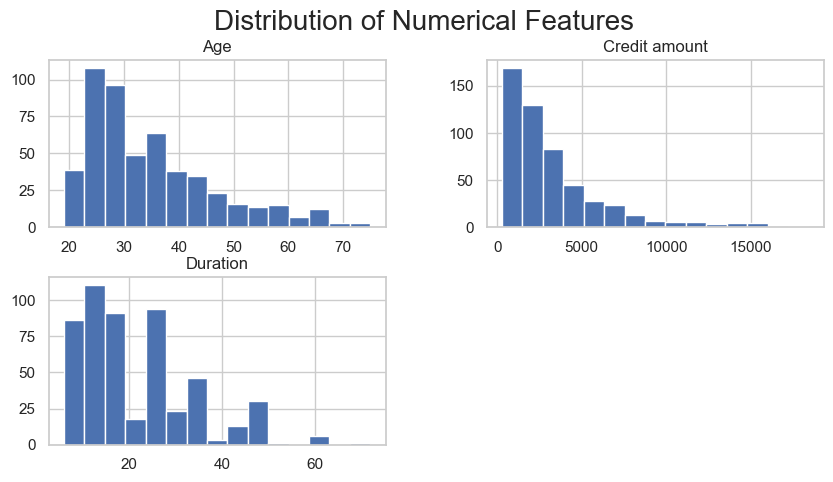

In [295]:
df[["Age", "Credit amount", "Duration"]].hist(bins=15, figsize=(10, 5))
plt.suptitle("Distribution of Numerical Features", fontsize=20)
plt.show()

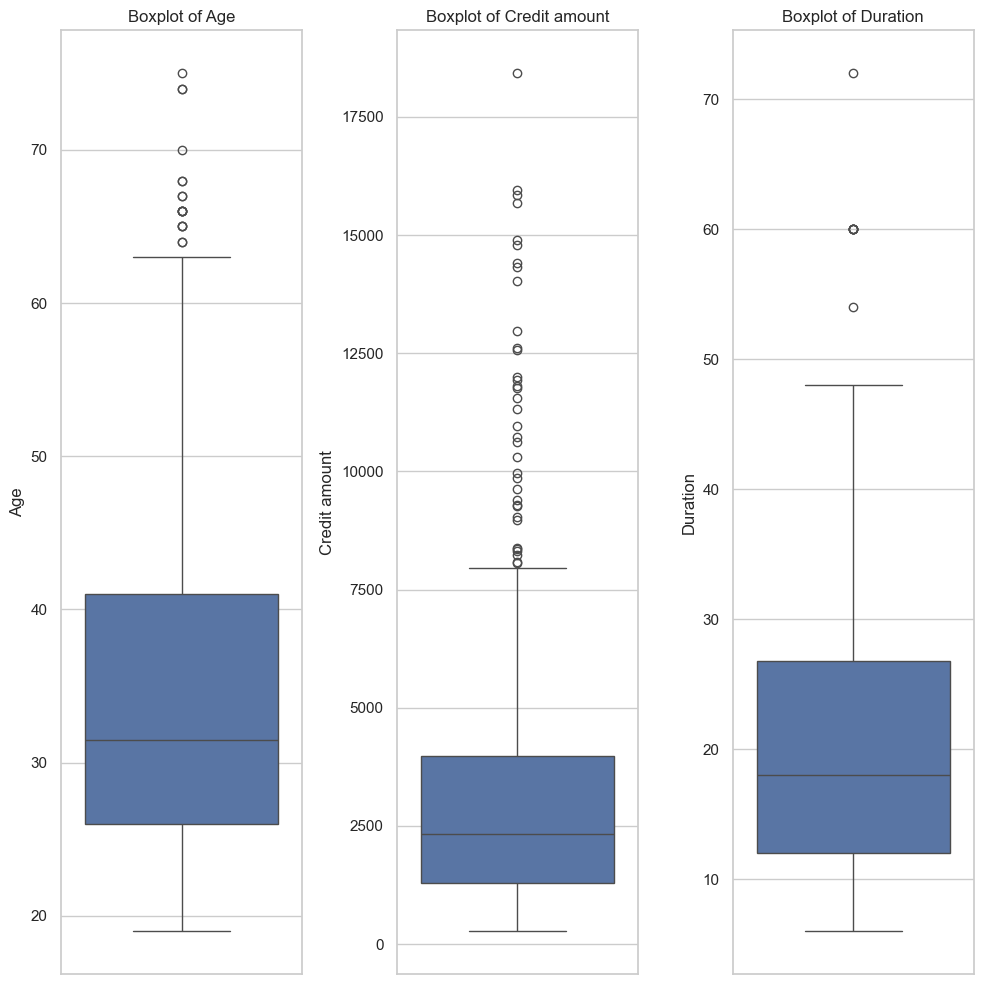

In [296]:
plt.figure(figsize=(10, 10))
for i , col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [297]:
df.query("Duration > 55")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [298]:
categorical_cols = [
    "Sex",
    "Job",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose",
    "Risk"
]


C:\Users\soumy\AppData\Local\Temp\ipykernel_27876\1817544893.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\soumy\AppData\Local\Temp\ipykernel_27876\1817544893.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\soumy\AppData\Local\Temp\ipykernel_27876\1817544893.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\soumy\AppData\Local\Temp\ipykernel_27876\1817544893.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to 

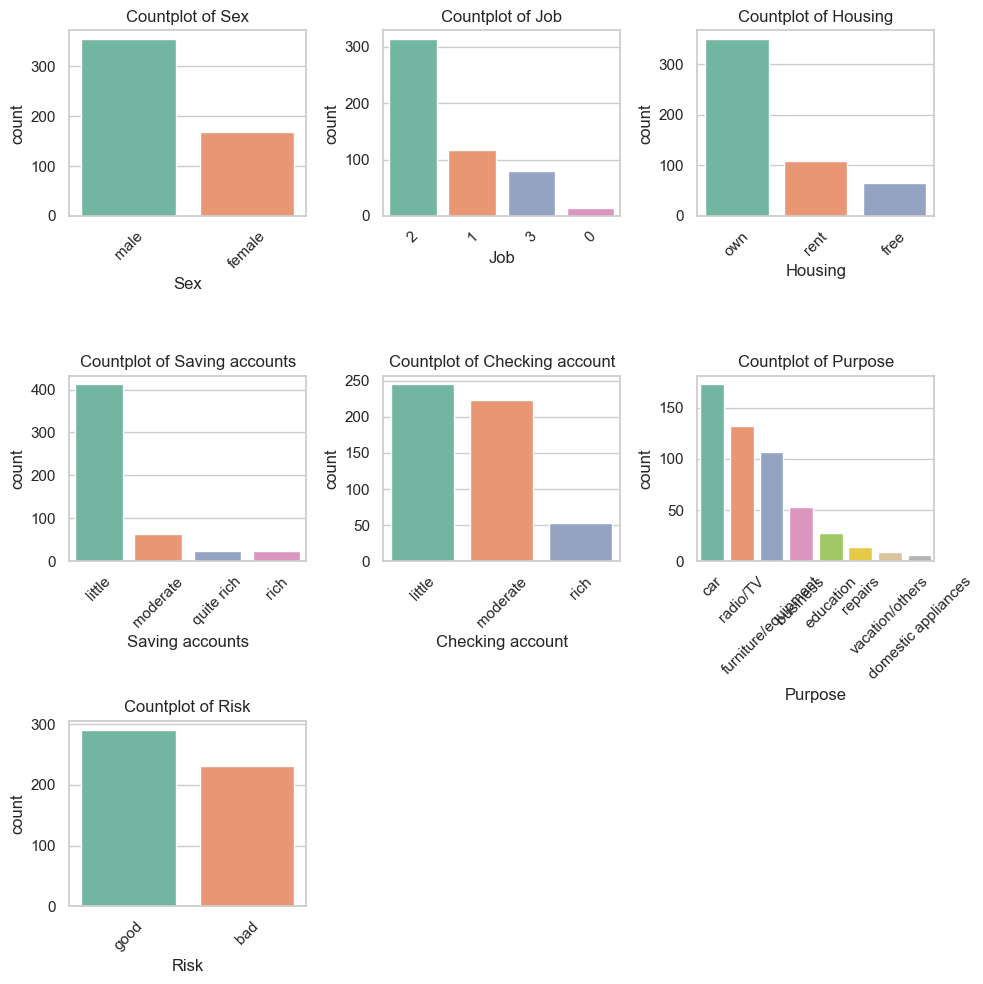

In [299]:
plt.figure(figsize=(10, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        palette="Set2"
    )
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [300]:
corr = df[["Age","Job","Credit amount", "Duration"]].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


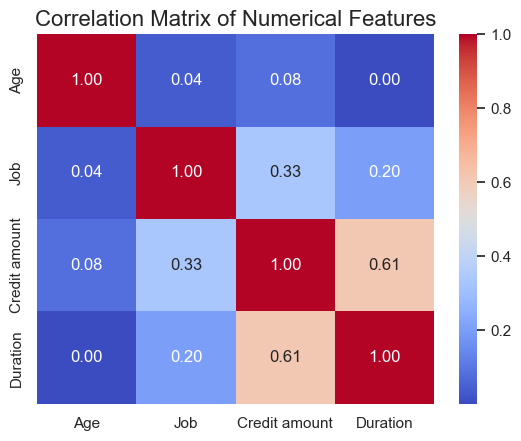

In [301]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features", fontsize=16)  
plt.show()

In [302]:
df.groupby("Risk")["Credit amount"].mean()

Risk
bad     3881.090909
good    2800.594502
Name: Credit amount, dtype: float64

In [303]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [304]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [305]:
pd.pivot_table(df, values="Credit amount", index="Housing", columns="Purpose", aggfunc=np.mean)

C:\Users\soumy\AppData\Local\Temp\ipykernel_27876\1687171763.py:1: FutureWarning: The provided callable <function mean at 0x000001ADF93E2B90> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pd.pivot_table(df, values="Credit amount", index="Housing", columns="Purpose", aggfunc=np.mean)


Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


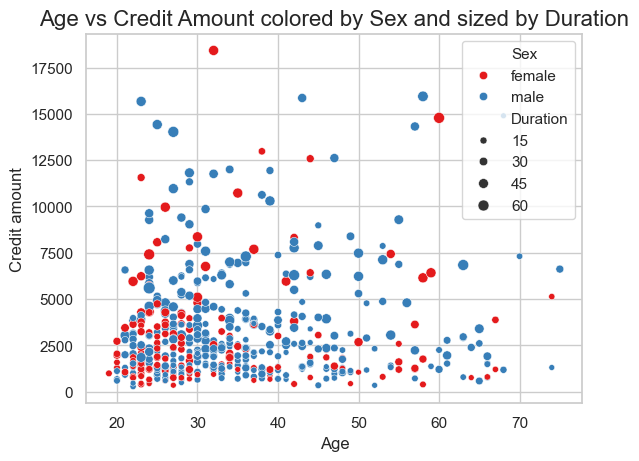

In [306]:
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex", size="Duration", palette="Set1")
plt.title("Age vs Credit Amount colored by Sex and sized by Duration", fontsize=16)
plt.show()

C:\Users\soumy\AppData\Local\Temp\ipykernel_27876\4118804386.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")


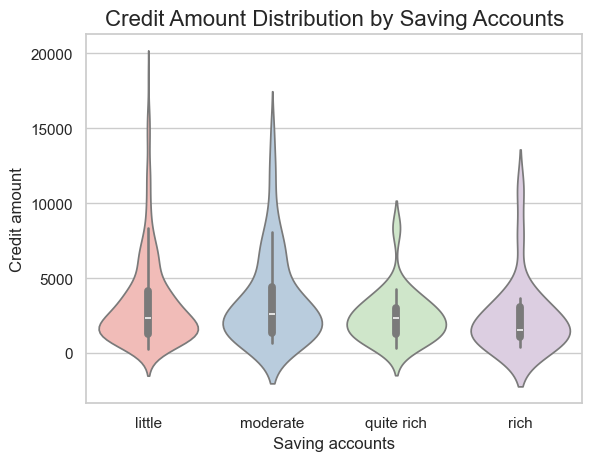

In [307]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")
plt.title("Credit Amount Distribution by Saving Accounts", fontsize=16)
plt.show()

In [308]:
df["Risk"].value_counts(normalize=True)*100


Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

C:\Users\soumy\AppData\Local\Temp\ipykernel_27876\3746979376.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x = "Risk", y=col, palette = "Pastel2")
C:\Users\soumy\AppData\Local\Temp\ipykernel_27876\3746979376.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x = "Risk", y=col, palette = "Pastel2")
C:\Users\soumy\AppData\Local\Temp\ipykernel_27876\3746979376.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x = "Risk", y=col, palette = "Pastel2")


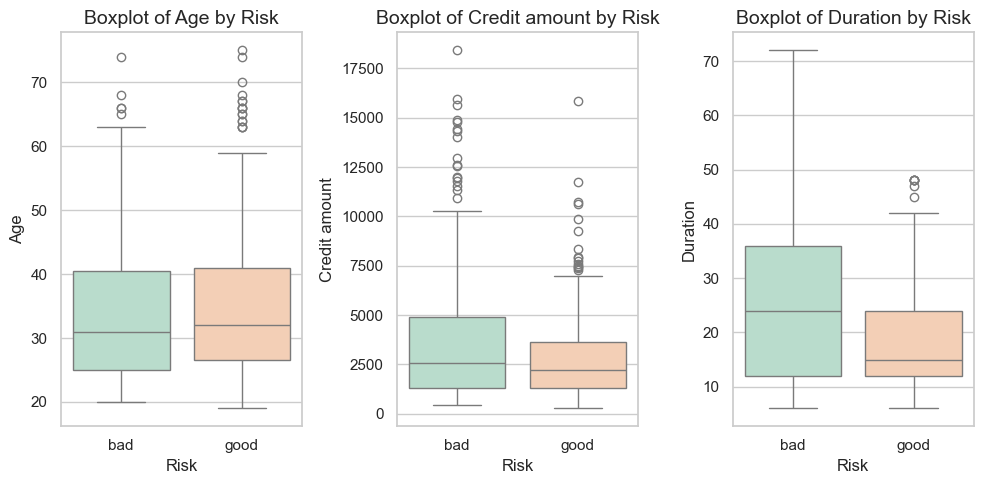

In [309]:
plt.figure(figsize=(10, 5))
for i ,col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df,x = "Risk", y=col, palette = "Pastel2")
    plt.title(f"Boxplot of {col} by Risk", fontsize=14)
plt.tight_layout()
plt.show()

In [310]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [311]:
categorical_cols

['Sex',
 'Job',
 'Housing',
 'Saving accounts',
 'Checking account',
 'Purpose',
 'Risk']

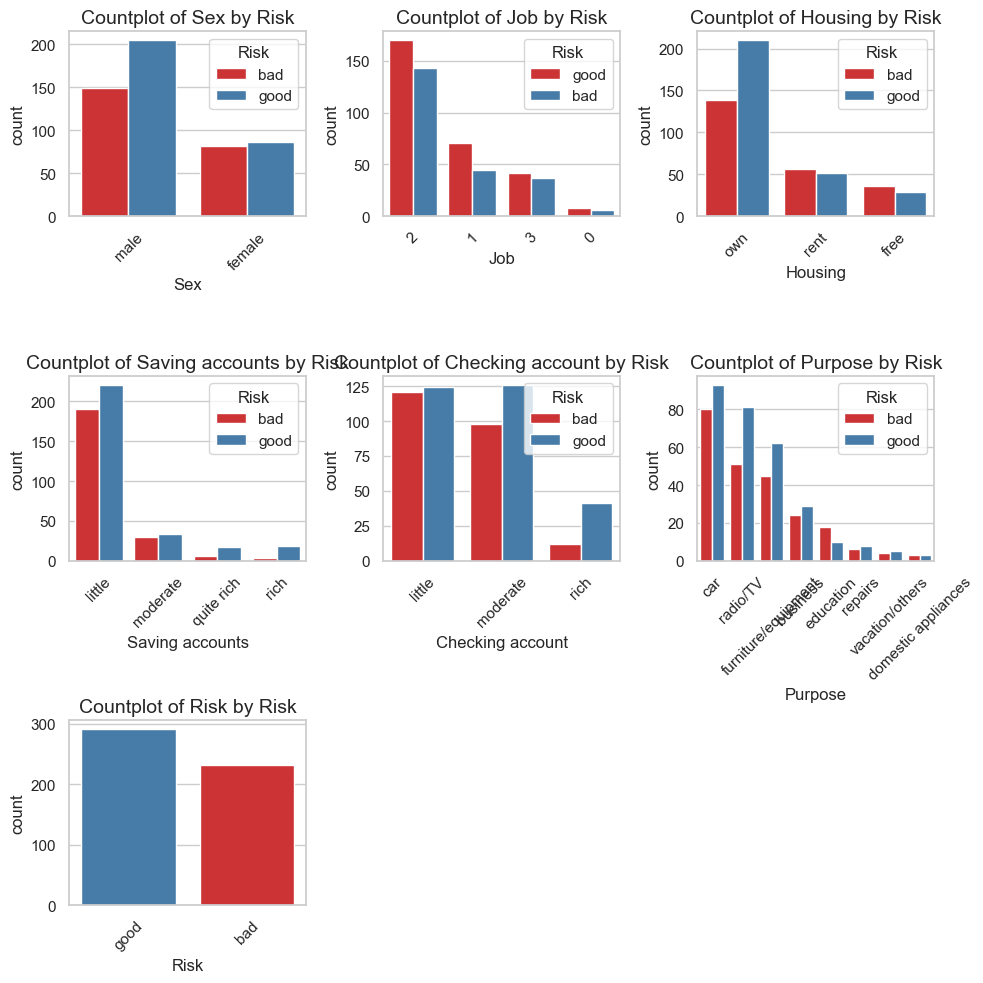

In [312]:
plt.figure(figsize=(10, 10))
for i ,cols in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=cols, hue="Risk", palette="Set1", order=df[cols].value_counts().index)
    plt.title(f"Countplot of {cols} by Risk", fontsize=14)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [313]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [314]:
features = ["Age","Sex","Job","Housing","Saving accounts","Checking account","Credit amount","Duration","Purpose"]

In [315]:
target = "Risk"


In [316]:
df_model = df[features + [target]].copy()

In [317]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad


In [318]:
from sklearn.preprocessing import LabelEncoder
import joblib


In [319]:
cat_cols = df_model.select_dtypes(include=['object']).columns.drop("Risk")

In [320]:
le_dict = {}

In [321]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')

In [322]:
for cols in cat_cols:
    le = LabelEncoder()
    df_model[cols] = le.fit_transform(df_model[cols])
    le_dict[cols] = le
    joblib.dump(le, f"{cols}_encoder.pkl")

In [323]:
le_target = LabelEncoder()

In [324]:
target

'Risk'

In [325]:
df_model[target] = le_target.fit_transform(df_model[target])

In [326]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [327]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [328]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,0,2,1,0,1,5951,48,5,0
1,45,1,2,0,0,0,7882,42,4,1
2,53,1,2,0,0,0,4870,24,1,0
3,35,1,3,2,0,1,6948,36,1,1
4,28,1,3,1,0,1,5234,30,1,0


In [329]:
from sklearn.model_selection import train_test_split

In [330]:
x = df_model.drop(columns=[target], axis=1)

In [331]:
y = df_model[target]

In [332]:
df ["Saving accounts"].unique()

array(['little', 'moderate', 'quite rich', 'rich'], dtype=object)

In [333]:
df["Checking account"].unique()

array(['moderate', 'little', 'rich'], dtype=object)

In [334]:
x

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,22,0,2,1,0,1,5951,48,5
1,45,1,2,0,0,0,7882,42,4
2,53,1,2,0,0,0,4870,24,1
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,1
...,...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24,5
518,30,1,3,1,0,0,3959,36,4
519,40,1,3,1,0,0,3857,30,1
520,23,1,2,0,0,0,1845,45,5


In [335]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [336]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=1)

In [337]:
x_train.shape

(417, 9)

In [338]:
x_test.shape

(105, 9)

In [339]:
%pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [340]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [341]:
def train_model(model,param_grid,x_train, y_train,x_test,y_test):
    grid = GridSearchCV(estimator=model, param_grid=param_grid,cv=5, n_jobs=-1, scoring='accuracy')
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    return best_model, accuracy,grid.best_params_

In [342]:
dt = DecisionTreeClassifier(random_state=1,class_weight='balanced')
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [343]:
best_dt,accuracy_dt,best_params_dt = train_model(dt,dt_param_grid,x_train, y_train,x_test,y_test)

In [344]:
print("Decission Tree Accuracy", accuracy_dt)

Decission Tree Accuracy 0.5904761904761905


In [345]:
print("Best parameters",best_params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [346]:
rf = RandomForestClassifier(random_state=1,class_weight='balanced',n_jobs=-1)


In [347]:
r1_param_grid ={
    'n_estimators': [100, 200],
    'max_depth': [5,7,10,None],
    'min_samples_split': [2, 5,10],
    'min_samples_leaf': [1, 2, 4]
}

In [348]:
best_rf, accuracy_rf,param_rf = train_model(rf,r1_param_grid,x_train, y_train,x_test,y_test)

In [349]:
print("Random Forest Accuracy", accuracy_rf)

Random Forest Accuracy 0.638095238095238


In [350]:
print("Best params:", param_rf)

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [351]:
et = ExtraTreesClassifier(random_state=1,class_weight='balanced',n_jobs=-1)


In [352]:
et_param_grid ={
    'n_estimators': [100, 200],
    'max_depth': [5,7,10,None],
    'min_samples_split': [2, 5,10],
    'min_samples_leaf': [1, 2, 4]
}

In [353]:
best_et, accuracy_et,param_et = train_model(et,et_param_grid,x_train, y_train,x_test,y_test)

In [354]:
print("Extra Trees Accuracy", accuracy_et)

Extra Trees Accuracy 0.638095238095238


In [355]:
print("Best Params:", param_et)

Best Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [356]:
xgb = XGBClassifier(random_state=1, scale_pos_weight= (y_train==0).sum() / (y_train==1).sum(), use_label_encoder=False, eval_metric='logloss')

In [357]:
xgb_param_grid ={
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7,1.0],
    'colsample_bytree': [0.7,1.0]
}

In [358]:
best_xgb, accuracy_xgb,param_xgb = train_model(xgb,xgb_param_grid,x_train, y_train,x_test,y_test)

c:\Users\soumy\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:50:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [359]:
print("XGB accuracy:", accuracy_xgb)

XGB accuracy: 0.6666666666666666


In [360]:
print("Best params:", param_xgb)

Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


In [361]:
best_et.predict(x_test)

array([1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1])

In [362]:
joblib.dump(best_et, "extra_trees_model.pkl")

['extra_trees_model.pkl']